<a href="https://colab.research.google.com/github/ariel07-sw/applied-data-in-econ/blob/main/econ-lab-24-causal-ml/notebooks/lab_ch24_diagnostic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 24: Causal ML — Double Machine Learning (Diagnostic Lab)
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 40 min Core + 20 min Extension

---

**Format:** This lab contains **deliberately flawed code**. Your job:
1. Run the code
2. Identify what is wrong (you are told how many bugs, not where)
3. Fix the issue
4. Verify on a known DGP
5. Extend with Causal Forests

**Learning Objectives:**
- Implement manual 2-fold cross-fitting from scratch and debug common mistakes
- Understand why cross-fitting, treatment residualization, and the IV-style formula are each essential
- Estimate the ATE of 401(k) eligibility using the DoubleML package
- Assess robustness with sensitivity analysis
- Fit a Causal Forest (EconML) to estimate individual-level CATEs
- Compare subgroup DML to Causal Forest heterogeneity detection

**Verification checkpoints** are provided so you can confirm you found the right errors.

**Time estimate:** ~60 minutes

---

In [1]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages and import libraries
# -----------------------------------------------------------
!pip install -q doubleml econml

from doubleml import DoubleMLData, DoubleMLPLR
from doubleml.datasets import fetch_401K
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LassoCV
from sklearn.model_selection import KFold
from econml.dml import CausalForestDML
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Load 401(k) data
data = fetch_401K(return_type='DataFrame')

print(f'Dataset shape: {data.shape}')
print(f'Columns: {list(data.columns)}')
print('Libraries loaded. Ready to diagnose.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 603.5/603.5 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.3/230.3 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.6 MB/s eta 0:00:00
Dataset shape: (9915, 14)
Columns: ['nifa', 'net_tfa', 'tw', 'age', 'inc', 'fsize', 'educ', 'db', 'marr', 'twoearn', 'e401', 'p401', 'pira', 'hown']
Libraries loaded. Ready to diagnose.


---

## Part A: Manual Cross-Fitting — DIAGNOSE

The code below attempts to implement the DML algorithm manually using
2-fold cross-fitting. It has **three deliberate bugs**:

1. **Bug 1 (Data Leakage):** Uses the same data for training AND residual computation — violates cross-fitting
2. **Bug 2 (Missing Residualization):** Only residualizes the outcome $Y$, not the treatment $D$
3. **Bug 3 (Wrong Formula):** Uses `np.mean` of residual products instead of the correct IV-style formula for $\hat{\theta}$

**Your task:** Find all three bugs, explain why each matters, and fix them.

**The correct DML formula:**

$$\hat{\theta} = \frac{\sum_i \tilde{D}_i \tilde{Y}_i}{\sum_i \tilde{D}_i D_i}$$

where $\tilde{Y}_i = Y_i - \hat{\ell}(X_i)$ and $\tilde{D}_i = D_i - \hat{m}(X_i)$ are
the residuals from cross-fitted nuisance models.

In [2]:
# -----------------------------------------------------------
# DIAGNOSE: This code has 3 bugs. Find and fix them all.
# Manual 2-fold cross-fitting DML
# -----------------------------------------------------------

# Generate simulated data with known ATE for verification
np.random.seed(42)
n = 5000
p = 100
TRUE_ATE = 5.0

X_sim = np.random.normal(0, 1, size=(n, p))
propensity = 1 / (1 + np.exp(-(0.5 * X_sim[:, 0] + 0.3 * X_sim[:, 1] + 0.2 * X_sim[:, 2])))
D_sim = np.random.binomial(1, propensity)
Y_sim = (TRUE_ATE * D_sim
         + 2.0 * X_sim[:, 0] + 1.5 * X_sim[:, 1] + 1.0 * X_sim[:, 2]
         + 0.5 * X_sim[:, 3] + 0.3 * X_sim[:, 4]
         + np.random.normal(0, 1, n))
def fixed_dml(Y, D, X, random_state=42):
    n = len(Y)
    kf = KFold(n_splits=2, shuffle=True, random_state=random_state)

    Y_tilde = np.zeros(n)
    D_tilde = np.zeros(n)

    for train_idx, test_idx in kf.split(X):
        # Outcome model: E[Y|X]
        ml_l = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
        ml_l.fit(X[train_idx], Y[train_idx])
        Y_hat = ml_l.predict(X[test_idx])
        Y_tilde[test_idx] = Y[test_idx] - Y_hat

        # Treatment model: E[D|X]
        ml_m = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
        ml_m.fit(X[train_idx], D[train_idx])
        D_hat = ml_m.predict(X[test_idx])
        D_tilde[test_idx] = D[test_idx] - D_hat

    theta = np.sum(D_tilde * Y_tilde) / np.sum(D_tilde * D)

    return theta

In [3]:
fixed_ate = fixed_dml(Y_sim, D_sim, X_sim)

print('=== FIXED DML Results ===')
print(f'True ATE:   {TRUE_ATE:.2f}')
print(f'Fixed ATE:  {fixed_ate:.2f}')
print(f'Bias:       {fixed_ate - TRUE_ATE:+.2f}')

=== FIXED DML Results ===
True ATE:   5.00
Fixed ATE:  5.17
Bias:       +0.17


In [6]:
# -----------------------------------------------------------
# YOUR TASK — Fix the broken DML implementation
# After fixing, verify on the simulated DGP (TRUE_ATE = 5.0)
# -----------------------------------------------------------

def fixed_dml(Y, D, X, random_state=42):
    """
    FIXED manual DML implementation.

    Fix 1: Cross-fit — train on one fold, predict on the other
    Fix 2: Residualize BOTH Y and D
    Fix 3: Use the IV-style formula: theta = sum(D_tilde * Y_tilde) / sum(D_tilde * D)
    """

    n = len(Y)
    kf = KFold(n_splits=2, shuffle=True, random_state=random_state)

    Y_tilde = np.zeros(n)
    D_tilde = np.zeros(n)

    for train_idx, test_idx in kf.split(X):
        # Outcome model
        ml_l = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
        ml_l.fit(X[train_idx], Y[train_idx])
        Y_hat = ml_l.predict(X[test_idx])
        Y_tilde[test_idx] = Y[test_idx] - Y_hat

        # Treatment model
        ml_m = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
        ml_m.fit(X[train_idx], D[train_idx])
        D_hat = ml_m.predict(X[test_idx])
        D_tilde[test_idx] = D[test_idx] - D_hat

    theta = np.sum(D_tilde * Y_tilde) / np.sum(D_tilde * D)
    return theta


# Verify on simulated data
fixed_ate = fixed_dml(Y_sim, D_sim, X_sim)

print('=== FIXED DML Results ===')
print(f'True ATE:    {TRUE_ATE:.2f}')
print(f'Fixed ATE:   {fixed_ate:.2f}')
print(f'Bias:        {fixed_ate - TRUE_ATE:+.2f}')
print()

# VERIFICATION CHECKPOINT
# Your fixed ATE should be within 0.5 of 5.0
# Expected: approximately 4.5 to 5.5
if abs(fixed_ate - TRUE_ATE) < 1.0:
    print('PASS — Fixed ATE is within 1.0 of the true value.')
else:
    print('FAIL — Fixed ATE is still far from 5.0. Check your fixes.')

=== FIXED DML Results ===
True ATE:    5.00
Fixed ATE:   5.17
Bias:        +0.17

PASS — Fixed ATE is within 1.0 of the true value.


---

## Part B: Package-Based DML

Now use the `doubleml` package to estimate the 401(k) ATE properly.
Less scaffolding than the 3916 lab — you should know the API from Part A.

In [9]:
print(globals().keys())
[c for c in globals().keys() if '401' in c.lower() or 'pension' in c.lower() or 'df' in c.lower()]

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', '_', '__', '___', '_i', '_ii', '_iii', '_i1', '_exit_code', 'DoubleMLData', 'DoubleMLPLR', 'fetch_401K', 'RandomForestRegressor', 'GradientBoostingRegressor', 'LassoCV', 'KFold', 'CausalForestDML', 'pd', 'np', 'plt', 'warnings', 'data', '_i2', 'n', 'p', 'TRUE_ATE', 'X_sim', 'propensity', 'D_sim', 'Y_sim', 'fixed_dml', '_i3', 'fixed_ate', '_i4', '_i6', '_i7', '_i8', '_i9'])


['fetch_401K']

In [14]:
# -----------------------------------------------------------
# YOUR TASK — Estimate the 401(k) ATE with DoubleML
# -----------------------------------------------------------

# Set up DoubleMLData
# y_col: 'net_tfa'
# d_cols: 'e401'
# x_cols: everything else

# YOUR CODE: Create dml_data, define nuisance learners, fit PLR
# Use RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
# for both ml_l and ml_m. Use n_folds=5.

# Set up DoubleMLData
x_cols = [col for col in data.columns if col not in ['net_tfa', 'e401', 'p401']]

dml_data = DoubleMLData(
    data,
    y_col='net_tfa',
    d_cols='e401',
    x_cols=x_cols
)

# Define nuisance learners
ml_l = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
ml_m = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)

# Fit PLR
dml_plr = DoubleMLPLR(
    dml_data,
    ml_l=ml_l,
    ml_m=ml_m,
    n_folds=5
)

dml_plr.fit()

# Output results
print(dml_plr.summary)
print(f'ATE: ${dml_plr.coef[0]:,.0f}')
print(f'95% CI: [{dml_plr.confint().iloc[0,0]:,.0f}, {dml_plr.confint().iloc[0,1]:,.0f}]')


# VERIFICATION CHECKPOINT
# Expected ATE: roughly $7,000-$12,000 (depends on random seed and model)
# Expected: statistically significant (p < 0.05)
# print(dml_plr.summary)
# print(f'ATE: ${dml_plr.coef[0]:,.0f}')
# print(f'95% CI: [{dml_plr.confint().iloc[0,0]:,.0f}, {dml_plr.confint().iloc[0,1]:,.0f}]')

           coef     std err          t         P>|t|        2.5 %      97.5 %
e401  8441.1537  422.442722  19.981771  7.935828e-89  7613.181179  9269.12622
ATE: $8,441
95% CI: [7,613, 9,269]


In [15]:
# -----------------------------------------------------------
# YOUR TASK — Run sensitivity analysis
# -----------------------------------------------------------

# Use dml_plr.sensitivity_analysis() to assess robustness
# Parameters:
#   cf_y = 0.03  (bound on confounding strength for outcome)
#   cf_d = 0.03  (bound on confounding strength for treatment)
#
# After running:
# 1. Print dml_plr.sensitivity_summary
# 2. Interpret the robustness value
#    - If robustness_value > 1: estimate is very robust
#    - If robustness_value < 1: an omitted variable of moderate
#      strength could flip the sign

dml_plr.sensitivity_analysis(cf_y=0.03, cf_d=0.03)

print(dml_plr.sensitivity_summary)
print(dml_plr.sensitivity_params)

# VERIFICATION CHECKPOINT
# The robustness value should be positive.
# A value > 0 means the estimate survives some degree of confounding.

================== Sensitivity Analysis ==================

------------------ Scenario          ------------------
Significance Level: level=0.95
Sensitivity parameters: cf_y=0.03; cf_d=0.03, rho=1.0

------------------ Bounds with CI    ------------------
         CI lower  theta lower      theta  theta upper      CI upper
e401  6526.511307  7253.598186  8441.1537  9628.709213  10297.035861

------------------ Robustness Values ------------------
      H_0    RV (%)    RVa (%)
e401  0.0  19.43384  17.424238
{'theta': {'lower': array([7253.59818633]), 'upper': array([9628.70921282])}, 'se': {'lower': array([442.03743554]), 'upper': array([406.31375184])}, 'ci': {'lower': array([6526.51130723]), 'upper': array([10297.03586121])}, 'rv': array([0.1943384]), 'rva': array([0.17424238]), 'input': {'cf_y': 0.03, 'cf_d': 0.03, 'rho': 1.0, 'level': 0.95, 'null_hypothesis': array([0.])}}


---

## Part C: Causal Forests (EXTEND)

DML estimates a single ATE (or subgroup ATEs if you manually split).
**Causal Forests** from the `econml` package estimate individual-level
Conditional Average Treatment Effects (CATEs) — a treatment effect
for every observation.

The `CausalForestDML` combines:
- DML-style cross-fitting for debiasing
- Random Forest splitting to discover heterogeneity
- Honesty: separate samples for splitting and estimation

In [ ]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Set up CausalForestDML from EconML
# -----------------------------------------------------------

# Prepare data arrays
y_col = 'net_tfa'
d_col = 'e401'
x_cols = [c for c in data.columns if c not in [y_col, d_col]]

Y = data[y_col].values
D = data[d_col].values.reshape(-1, 1)
X = data[x_cols].values

print(f'Y shape: {Y.shape}')
print(f'D shape: {D.shape}')
print(f'X shape: {X.shape}')
print(f'Covariates: {x_cols}')
print()

# Initialize CausalForestDML
cf = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
    model_t=RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
    n_estimators=500,   # Number of causal trees
    min_samples_leaf=20,
    max_depth=10,
    random_state=42,
    cv=5                # Cross-fitting folds
)

print('CausalForestDML configured.')
print('Next: fit the model and extract individual CATEs.')

In [19]:
# ------------------------------------------------------------
# GUIDED — Run as-is
# Set up CausalForestDML from EconML
# ------------------------------------------------------------

# Prepare data arrays
raw_401k = fetch_401K(return_type='DataFrame')

y_col = 'net_tfa'
d_col = 'e401'
x_cols = [c for c in raw_401k.columns if c not in [y_col, d_col]]

Y = raw_401k[y_col].values
D = raw_401k[d_col].values
X = raw_401k[x_cols].values

print(f'Y shape: {Y.shape}')
print(f'D shape: {D.shape}')
print(f'X shape: {X.shape}')
print(f'Covariates: {x_cols}')
print()

# Initialize CausalForestDML
cf = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
    model_t=RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
    n_estimators=500,
    min_samples_leaf=20,
    max_depth=10,
    random_state=42,
    cv=5
)

print('CausalForestDML configured.')
print('Next: fit the model and extract individual CATEs.')

Y shape: (9915,)
D shape: (9915,)
X shape: (9915, 12)
Covariates: ['nifa', 'tw', 'age', 'inc', 'fsize', 'educ', 'db', 'marr', 'twoearn', 'p401', 'pira', 'hown']

CausalForestDML configured.
Next: fit the model and extract individual CATEs.


In [22]:
# Fit the Causal Forest model
cf.fit(Y, D, X=X)

# Extract individual CATE predictions
cate_hat = cf.effect(X)
cate_predictions = cate_hat

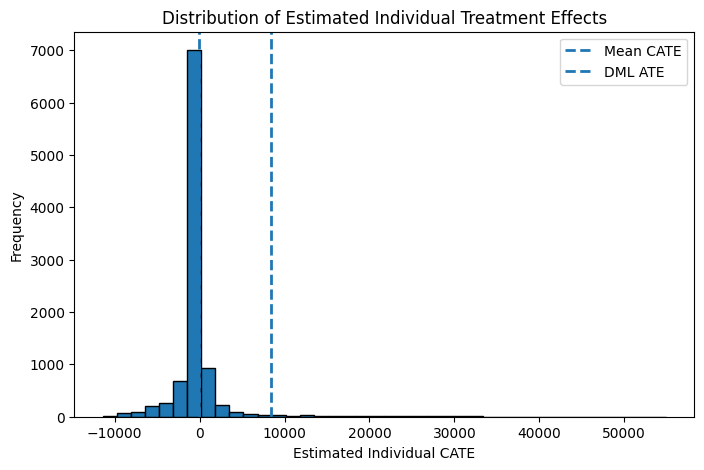

75th percentile threshold: 109.93
High-response group size: 2479
Low-response group size: 7436

       high_response_mean  low_response_mean
age             43.762808          40.159225
inc          34052.519531       38250.128906
educ            13.111739          13.237762
fsize            2.449778           3.004572
p401             0.230335           0.272055


In [23]:
# -----------------------------------------------------------
# YOUR TASK — Create CATE histogram and identify high-response subgroup
# -----------------------------------------------------------

# Step 1: Plot a histogram of individual CATE estimates
# Include a vertical line at the mean CATE and the DML ATE for comparison

cate_predictions = cate_hat

plt.figure(figsize=(8, 5))
plt.hist(cate_predictions, bins=40, edgecolor='black')
plt.axvline(cate_predictions.mean(), linestyle='--', linewidth=2, label='Mean CATE')
plt.axvline(dml_plr.coef[0], linestyle='--', linewidth=2, label='DML ATE')
plt.xlabel('Estimated Individual CATE')
plt.ylabel('Frequency')
plt.title('Distribution of Estimated Individual Treatment Effects')
plt.legend()
plt.show()


# Step 2: Identify the "high-response" subgroup
# Define high-response as individuals with CATE above the 75th percentile
# Compare their characteristics to the rest of the sample

# Hint:
# threshold = np.percentile(cate_predictions, 75)
# high_resp = data[cate_predictions >= threshold]
# low_resp = data[cate_predictions < threshold]
# Compare mean income, age, education, etc.

threshold = np.percentile(cate_predictions, 75)

results_cf = raw_401k.copy()
results_cf['cate_hat'] = cate_predictions

high_resp = results_cf[results_cf['cate_hat'] >= threshold]
low_resp = results_cf[results_cf['cate_hat'] < threshold]

print(f'75th percentile threshold: {threshold:,.2f}')
print(f'High-response group size: {len(high_resp)}')
print(f'Low-response group size: {len(low_resp)}')
print()

compare_cols = ['age', 'inc', 'educ', 'fsize', 'nettfa', 'p401']
compare_cols = [c for c in compare_cols if c in results_cf.columns]

comparison = pd.DataFrame({
    'high_response_mean': high_resp[compare_cols].mean(),
    'low_response_mean': low_resp[compare_cols].mean()
})

print(comparison)


# VERIFICATION CHECKPOINT
# The high-response subgroup should have systematically different
# characteristics (e.g., higher income, different age profile).
# If all subgroup means are identical, something went wrong.

=== Mean CATE by income quartile ===
                    mean          std  count
inc_quartile                                
Q1            -34.580482  1968.490550   2481
Q2            187.093521  3817.694616   2477
Q3           -280.377104  2675.437827   2478
Q4              2.484672  6336.251396   2479

=== Within-quartile heterogeneity ===
Q1: mean=-34.58, std=1,968.49, min=-7,866.95, max=54,958.74
Q2: mean=187.09, std=3,817.69, min=-10,328.04, max=54,175.68
Q3: mean=-280.38, std=2,675.44, min=-10,145.45, max=28,267.30
Q4: mean=2.48, std=6,336.25, min=-11,436.28, max=32,422.58

Between-quartile range in mean CATE: 467.47
Average within-quartile std of CATE: 3,699.47



<Figure size 900x500 with 0 Axes>

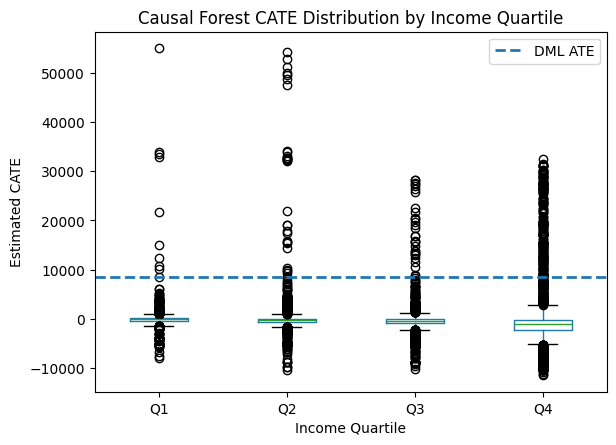


Key question: Does the Causal Forest reveal heterogeneity
WITHIN income quartiles that subgroup DML would miss?


In [24]:
# ------------------------------------------------------------
# EXTEND — Compare subgroup DML to Causal Forest CATE
# ------------------------------------------------------------

# The 3916 lab estimated CATE by income quartile using subgroup DML.
# Here we compare that coarse approach to the Causal Forest's
# continuous CATE predictions.

# Make sure we have a dataframe with CATEs
results_cf = raw_401k.copy()
results_cf['cate_hat'] = cate_hat

# Step 1: Compute mean Causal Forest CATE by income quartile
results_cf['inc_quartile'] = pd.qcut(results_cf['inc'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

quartile_summary = results_cf.groupby('inc_quartile')['cate_hat'].agg(['mean', 'std', 'count'])
print("=== Mean CATE by income quartile ===")
print(quartile_summary)
print()

# Step 2: Within each income quartile, how much variation remains?
print("=== Within-quartile heterogeneity ===")
for q in ['Q1', 'Q2', 'Q3', 'Q4']:
    q_data = results_cf[results_cf['inc_quartile'] == q]
    print(
        f"{q}: mean={q_data['cate_hat'].mean():,.2f}, "
        f"std={q_data['cate_hat'].std():,.2f}, "
        f"min={q_data['cate_hat'].min():,.2f}, "
        f"max={q_data['cate_hat'].max():,.2f}"
    )
print()

between_range = quartile_summary['mean'].max() - quartile_summary['mean'].min()
avg_within_std = quartile_summary['std'].mean()

print(f"Between-quartile range in mean CATE: {between_range:,.2f}")
print(f"Average within-quartile std of CATE: {avg_within_std:,.2f}")
print()

# Step 3: Visualize distribution within each quartile
plt.figure(figsize=(9, 5))
results_cf.boxplot(column='cate_hat', by='inc_quartile', grid=False)
plt.axhline(dml_plr.coef[0], linestyle='--', linewidth=2, label='DML ATE')
plt.suptitle('')
plt.title('Causal Forest CATE Distribution by Income Quartile')
plt.xlabel('Income Quartile')
plt.ylabel('Estimated CATE')
plt.legend()
plt.show()

print('\nKey question: Does the Causal Forest reveal heterogeneity')
print('WITHIN income quartiles that subgroup DML would miss?')

---

## Reflection

Answer in 3-5 sentences:

**When would you choose DML for ATE estimation vs. Causal Forests for CATE estimation?**

Consider:
- What is your research question? (average policy effect vs. targeting)
- How much data do you have? (CATE requires more observations per subgroup)
- How interpretable do the results need to be? (ATE is a single number; CATE is a distribution)
- What are the credibility concerns? (ATE with sensitivity analysis vs. CATE with wider CIs)

*Your answer:*
I would choose DML when my main goal is to estimate a credible average treatment effect, especially if I want a single interpretable number for policy evaluation. DML is also a better choice when the sample size is limited, because CATE estimation requires much more data to detect reliable heterogeneity. I would choose Causal Forests when the research question is about targeting or understanding which subgroups benefit more, since it estimates heterogeneous effects at the individual level. However, Causal Forest results are usually harder to interpret and often come with greater uncertainty, so they are best used when heterogeneity is central to the question.

---

## Digital Portfolio: Institutional Signaling

### Generate Your Professional README

Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

```text
"I need help writing a project description for my data science lab.
**Important Rule:** Do NOT generate any Python code for me.

**What I did in this lab:**
* Diagnosed and fixed a broken manual DML implementation (3 bugs:
  data leakage in cross-fitting, missing treatment residualization,
  wrong IV-formula for theta)
* Verified the fix recovers the true ATE (=5.0) on a simulated DGP
* Estimated the ATE of 401(k) eligibility on net financial assets
  using DoubleML with Random Forest nuisance learners and 5-fold cross-fitting
* Ran sensitivity analysis to assess robustness to unmeasured confounders
* Fit a CausalForestDML (EconML) to estimate individual-level CATEs
* Compared subgroup DML (quartile-level) to Causal Forest (individual-level)
  heterogeneity detection
* Key finding: [FILL IN — ATE, robustness, which method reveals finer heterogeneity?]

**Please write a README.md entry including:**
1. Project Title: Causal ML — DML and Causal Forests for Policy Evaluation
2. Objective: A professional one-sentence summary
3. Methodology: Bullet points of technical steps
4. Key Findings: Summary of results
Make this sound like a professional tech economist wrote it.
```

### Push to GitHub

```bash
cd econ-lab-24-causal-ml
git add notebooks/ figures/ README.md
git commit -m "Lab 24: Causal ML — DML & Causal Forests for 401(k) Policy"
git push origin main
```

Submit your GitHub repo link on Canvas.